<a href="https://colab.research.google.com/github/Gracehotchkiss/bse-ts-public/blob/main/HW1_MLforFin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW1 – ML for Finance (BSE 2026)
**Team Members:** *Grace Hothckiss, Charley Baker, Louise Knight*  
**Assigned indicators (Task 2):** `bm`, `ep`, `ntis`

---
## Contents
1. Setup & Data
2. **Task 1** – Granger Causality Network & Volatility Spillover
3. **Task 2** – NN vs LSTM vs Gaussian Process
4. **Task 3** – ARMA+GARCH baseline
5. **Task 4** – Lecture summaries


---
# 0. Install & Import Libraries

In [15]:
!pip install yfinance arch dcor tabulate --quiet

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Finance / Stats
import yfinance as yf
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from arch import arch_model
import statsmodels.api as sm
import dcor

# ML
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel, Matern, DotProduct
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Network visualization
import networkx as nx
from tabulate import tabulate

np.random.seed(42)
tf.random.set_seed(42)
print('All libraries loaded.')

All libraries loaded.


---
# TASK 1 – Global Asset Causal Network & Volatility Spillover

**Assets:** SPY, XLK, XLF, XLE, GLD, SLV, GSG, BTC-USD, ETH-USD, TLT  
**Steps:**  
- Compute log returns and EWMA volatility  
- Resample to weekly & monthly  
- Pairwise Granger causality (optimal lag via AIC in [1,5])  
- Four 10×10 tables + network plots

## 1.1 Download Data

In [17]:
# ── CHANGE THESE DATES TO YOUR ASSIGNED EPOCH ──
START_DATE = '2018-01-01'
END_DATE   = '2024-01-01'

ASSETS = ['SPY','XLK','XLF','XLE','GLD','SLV','GSG','BTC-USD','ETH-USD','TLT']
ASSET_LABELS = ['SPY','XLK','XLF','XLE','GLD','SLV','GSG','BTC','ETH','TLT']

raw = yf.download(ASSETS, start=START_DATE, end=END_DATE, auto_adjust=True)['Close']
raw.columns = ASSET_LABELS
raw.dropna(how='all', inplace=True)

# Forward-fill any remaining NaN (crypto trades every day; equities don't)
raw.ffill(inplace=True)
print(f'Shape: {raw.shape}')
print(f'Missing values:\n{raw.isnull().sum()}')
raw.tail()

[*********************100%***********************]  10 of 10 completed


Shape: (2191, 10)
Missing values:
SPY    0
XLK    0
XLF    1
XLE    1
GLD    1
SLV    1
GSG    1
BTC    1
ETH    1
TLT    1
dtype: int64


,SPY,XLK,XLF,XLE,GLD,SLV,GSG,BTC,ETH,TLT
Date,,,,,,,,,,
2023-12-27,43442.855469,2378.739990,192.589996,20.480000,22.230000,463.747864,91.071838,39.701305,36.333321,95.052200
2023-12-28,42627.855469,2347.566162,191.470001,20.180000,21.990000,463.923004,90.410385,39.096451,36.439575,95.165581
2023-12-29,42099.402344,2300.690674,191.169998,20.059999,21.780001,462.579987,89.594925,39.008049,36.323650,94.874763
2023-12-30,42156.902344,2292.065430,191.169998,20.059999,21.780001,462.579987,89.594925,39.008049,36.323650,94.874763
2023-12-31,42265.187500,2281.471191,191.169998,20.059999,21.780001,462.579987,89.594925,39.008049,36.323650,94.874763


## 1.2 Compute Returns & EWMA Volatility

In [18]:
# Daily log returns
daily_ret = np.log(raw / raw.shift(1)).dropna()

# EWMA Volatility (λ = 0.94, RiskMetrics standard)
LAMBDA = 0.94
daily_vol = daily_ret.copy() * 0
daily_vol.iloc[0] = daily_ret.iloc[0] ** 2
for t in range(1, len(daily_ret)):
    daily_vol.iloc[t] = LAMBDA * daily_vol.iloc[t-1] + (1 - LAMBDA) * daily_ret.iloc[t] ** 2
daily_vol = np.sqrt(daily_vol)   # convert variance → std dev

print('Daily returns shape:', daily_ret.shape)
print('Daily EWMA vol shape:', daily_vol.shape)

Daily returns shape: (2189, 10)
Daily EWMA vol shape: (2189, 10)


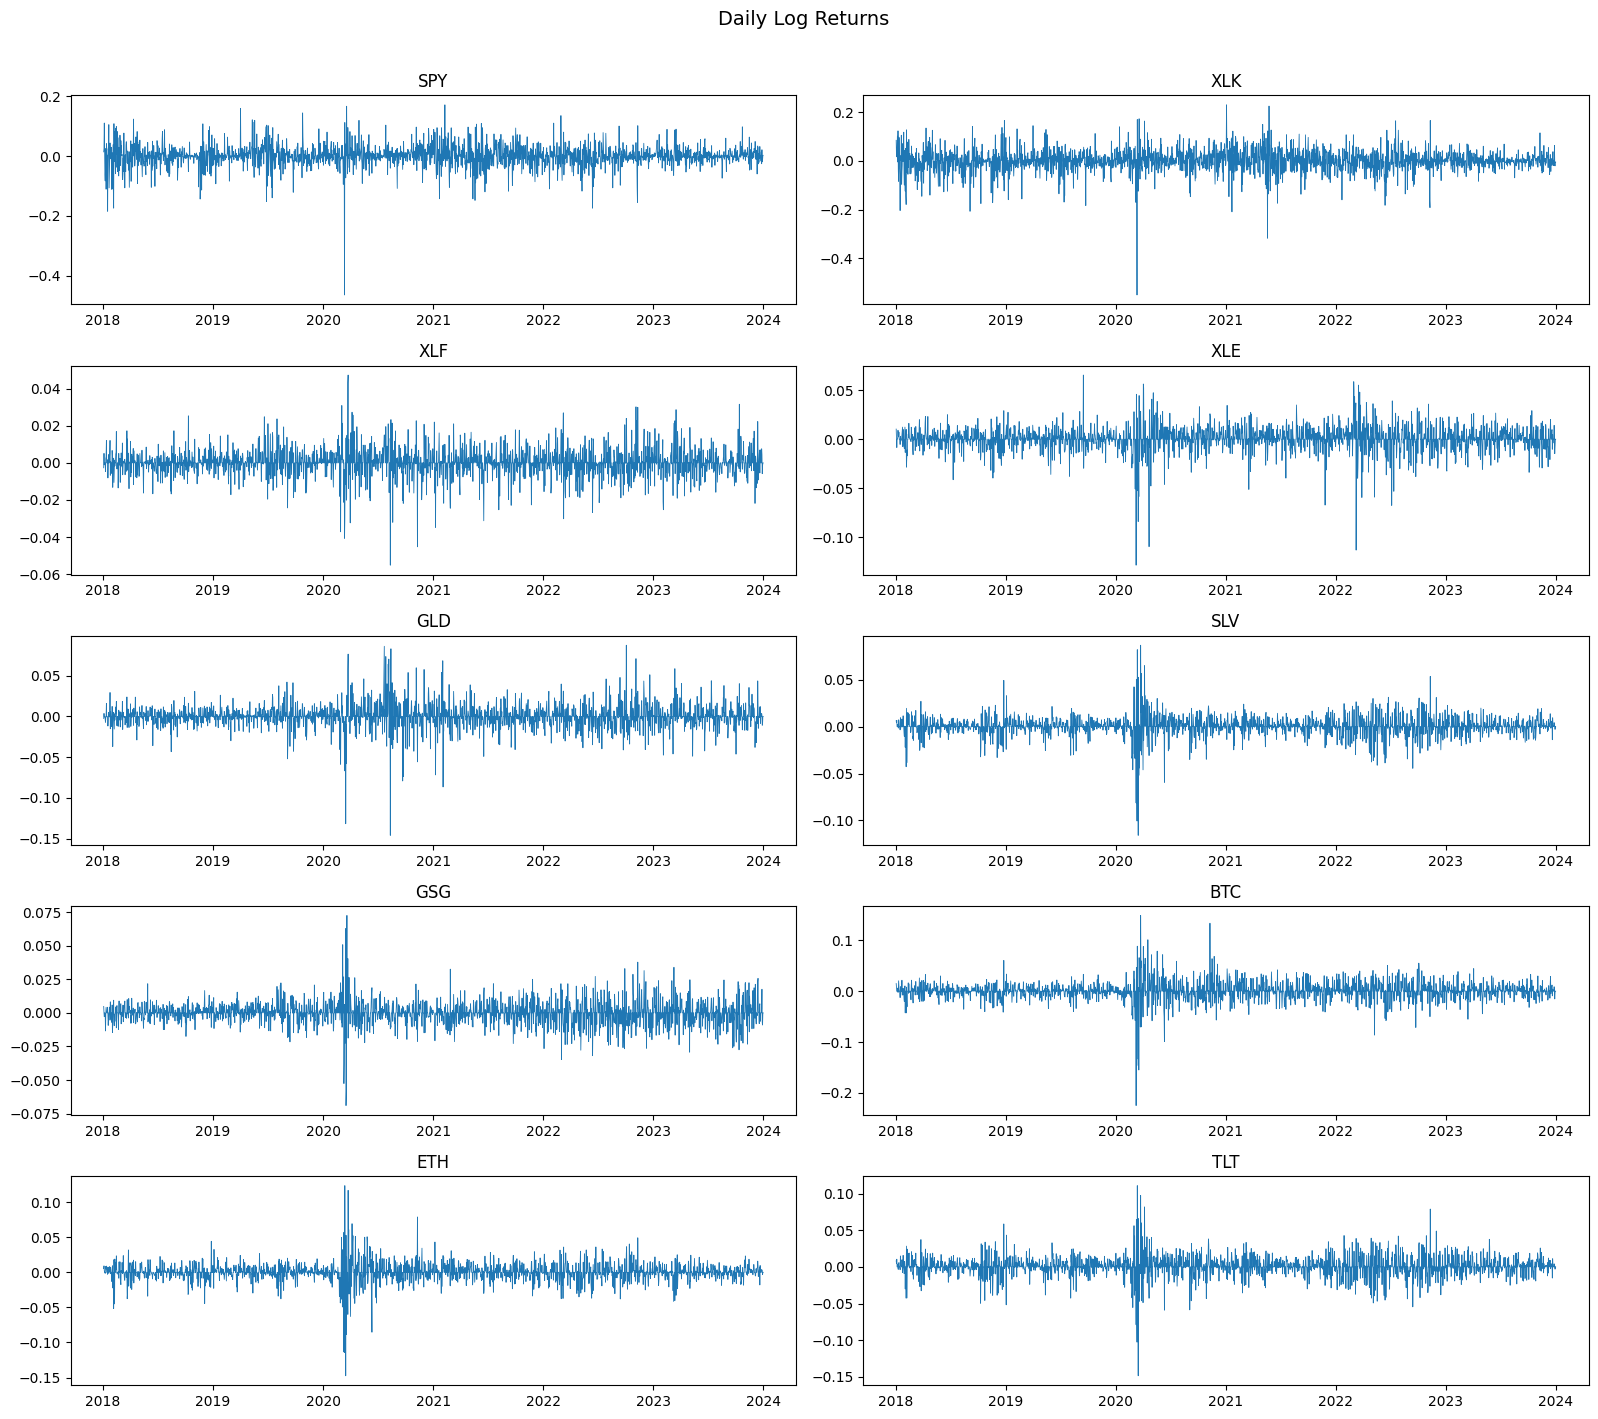

In [19]:
# Plot returns overview
fig, axes = plt.subplots(5, 2, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(ASSET_LABELS):
    axes[i].plot(daily_ret.index, daily_ret[col], lw=0.6)
    axes[i].set_title(col)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.suptitle('Daily Log Returns', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('daily_returns.png', dpi=120, bbox_inches='tight')
plt.show()

In [20]:
# Resample to weekly (last obs) and monthly (last obs)
weekly_ret  = daily_ret.resample('W').sum()    # sum of daily log-rets ≈ weekly log-ret
monthly_ret = daily_ret.resample('ME').sum()

weekly_vol  = daily_vol.resample('W').last()
monthly_vol = daily_vol.resample('ME').last()

# Drop rows with any NaN after resampling
weekly_ret.dropna(inplace=True)
monthly_ret.dropna(inplace=True)
weekly_vol.dropna(inplace=True)
monthly_vol.dropna(inplace=True)

print('Weekly  returns:', weekly_ret.shape,  '| Monthly returns:', monthly_ret.shape)
print('Weekly  vol:    ', weekly_vol.shape,  '| Monthly vol:    ', monthly_vol.shape)

Weekly  returns: (313, 10) | Monthly returns: (72, 10)
Weekly  vol:     (313, 10) | Monthly vol:     (72, 10)


## 1.3 Pairwise Granger Causality Helper Functions

In [21]:
def optimal_lag_aic(x, y, max_lag=5):
    """Find optimal lag for pair (x→y) using VAR AIC in range [1, max_lag]."""
    df = pd.concat([y, x], axis=1).dropna()
    best_aic = np.inf
    best_lag = 1
    for lag in range(1, max_lag + 1):
        try:
            model = VAR(df)
            result = model.fit(lag, trend='c')
            if result.aic < best_aic:
                best_aic = result.aic
                best_lag = lag
        except:
            pass
    return best_lag

def granger_pvalue(x, y, lag):
    """Return p-value for Granger causality x→y at given lag."""
    df = pd.concat([y, x], axis=1).dropna()
    try:
        result = grangercausalitytests(df, maxlag=lag, verbose=False)
        # Use the F-test p-value at the specified lag
        pval = result[lag][0]['ssr_ftest'][1]
        return pval
    except:
        return 1.0

def build_causality_table(data, assets=ASSET_LABELS, max_lag=5, alpha=0.05):
    """
    Build NxN causality table.
    Entry [i,j] = optimal lag l if asset[i] Granger-causes asset[j] at 5% level, else 0.
    Rows = cause, Columns = effect.
    """
    n = len(assets)
    table = pd.DataFrame(np.zeros((n, n), dtype=int), index=assets, columns=assets)

    for i, cause in enumerate(assets):
        for j, effect in enumerate(assets):
            if i == j:
                table.loc[cause, effect] = -1  # diagonal
                continue
            lag = optimal_lag_aic(data[cause], data[effect], max_lag)
            pval = granger_pvalue(data[cause], data[effect], lag)
            table.loc[cause, effect] = lag if pval < alpha else 0

    return table

print('Helper functions defined.')

Helper functions defined.


## 1.4 Compute All Four Causality Tables
> ⏱ This cell may take a few minutes (10×9×4 = 360 pair tests)

In [22]:
print('Computing weekly RETURN causality table...')
table_ret_weekly = build_causality_table(weekly_ret)

print('Computing monthly RETURN causality table...')
table_ret_monthly = build_causality_table(monthly_ret)

print('Computing weekly VOLATILITY causality table...')
table_vol_weekly = build_causality_table(weekly_vol)

print('Computing monthly VOLATILITY causality table...')
table_vol_monthly = build_causality_table(monthly_vol)

print('Done!')

Computing weekly RETURN causality table...
Computing monthly RETURN causality table...
Computing weekly VOLATILITY causality table...
Computing monthly VOLATILITY causality table...
Done!


## 1.5 Display Tables

In [23]:
def display_table(df, title):
    display_df = df.copy().astype(object)
    for i in range(len(df)):
        display_df.iloc[i, i] = '-'
    print(f'\n=== {title} ===' )
    print(tabulate(display_df, headers='keys', tablefmt='grid'))

display_table(table_ret_weekly,  'Returns – WEEKLY  (row→col = cause→effect, value=lag, 0=no causality)')
display_table(table_ret_monthly, 'Returns – MONTHLY (row→col = cause→effect, value=lag, 0=no causality)')
display_table(table_vol_weekly,  'Volatility – WEEKLY  (row→col = cause→effect, value=lag, 0=no causality)')
display_table(table_vol_monthly, 'Volatility – MONTHLY (row→col = cause→effect, value=lag, 0=no causality)')


=== Returns – WEEKLY  (row→col = cause→effect, value=lag, 0=no causality) ===
+-----+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
|     | SPY   | XLK   | XLF   | XLE   | GLD   | SLV   | GSG   | BTC   | ETH   | TLT   |
+=====+=======+=======+=======+=======+=======+=======+=======+=======+=======+=======+
| SPY | -     | 0     | 0     | 1     | 2     | 1     | 0     | 1     | 5     | 1     |
+-----+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
| XLK | 0     | -     | 0     | 1     | 1     | 1     | 0     | 1     | 1     | 1     |
+-----+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
| XLF | 2     | 0     | -     | 0     | 0     | 0     | 0     | 0     | 0     | 0     |
+-----+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
| XLE | 0     | 0     | 1     | -     | 0     | 0     | 1     | 0     | 0     | 0     |
+-----+-------+-------+-------+-------+--

## 1.6 Network Plots

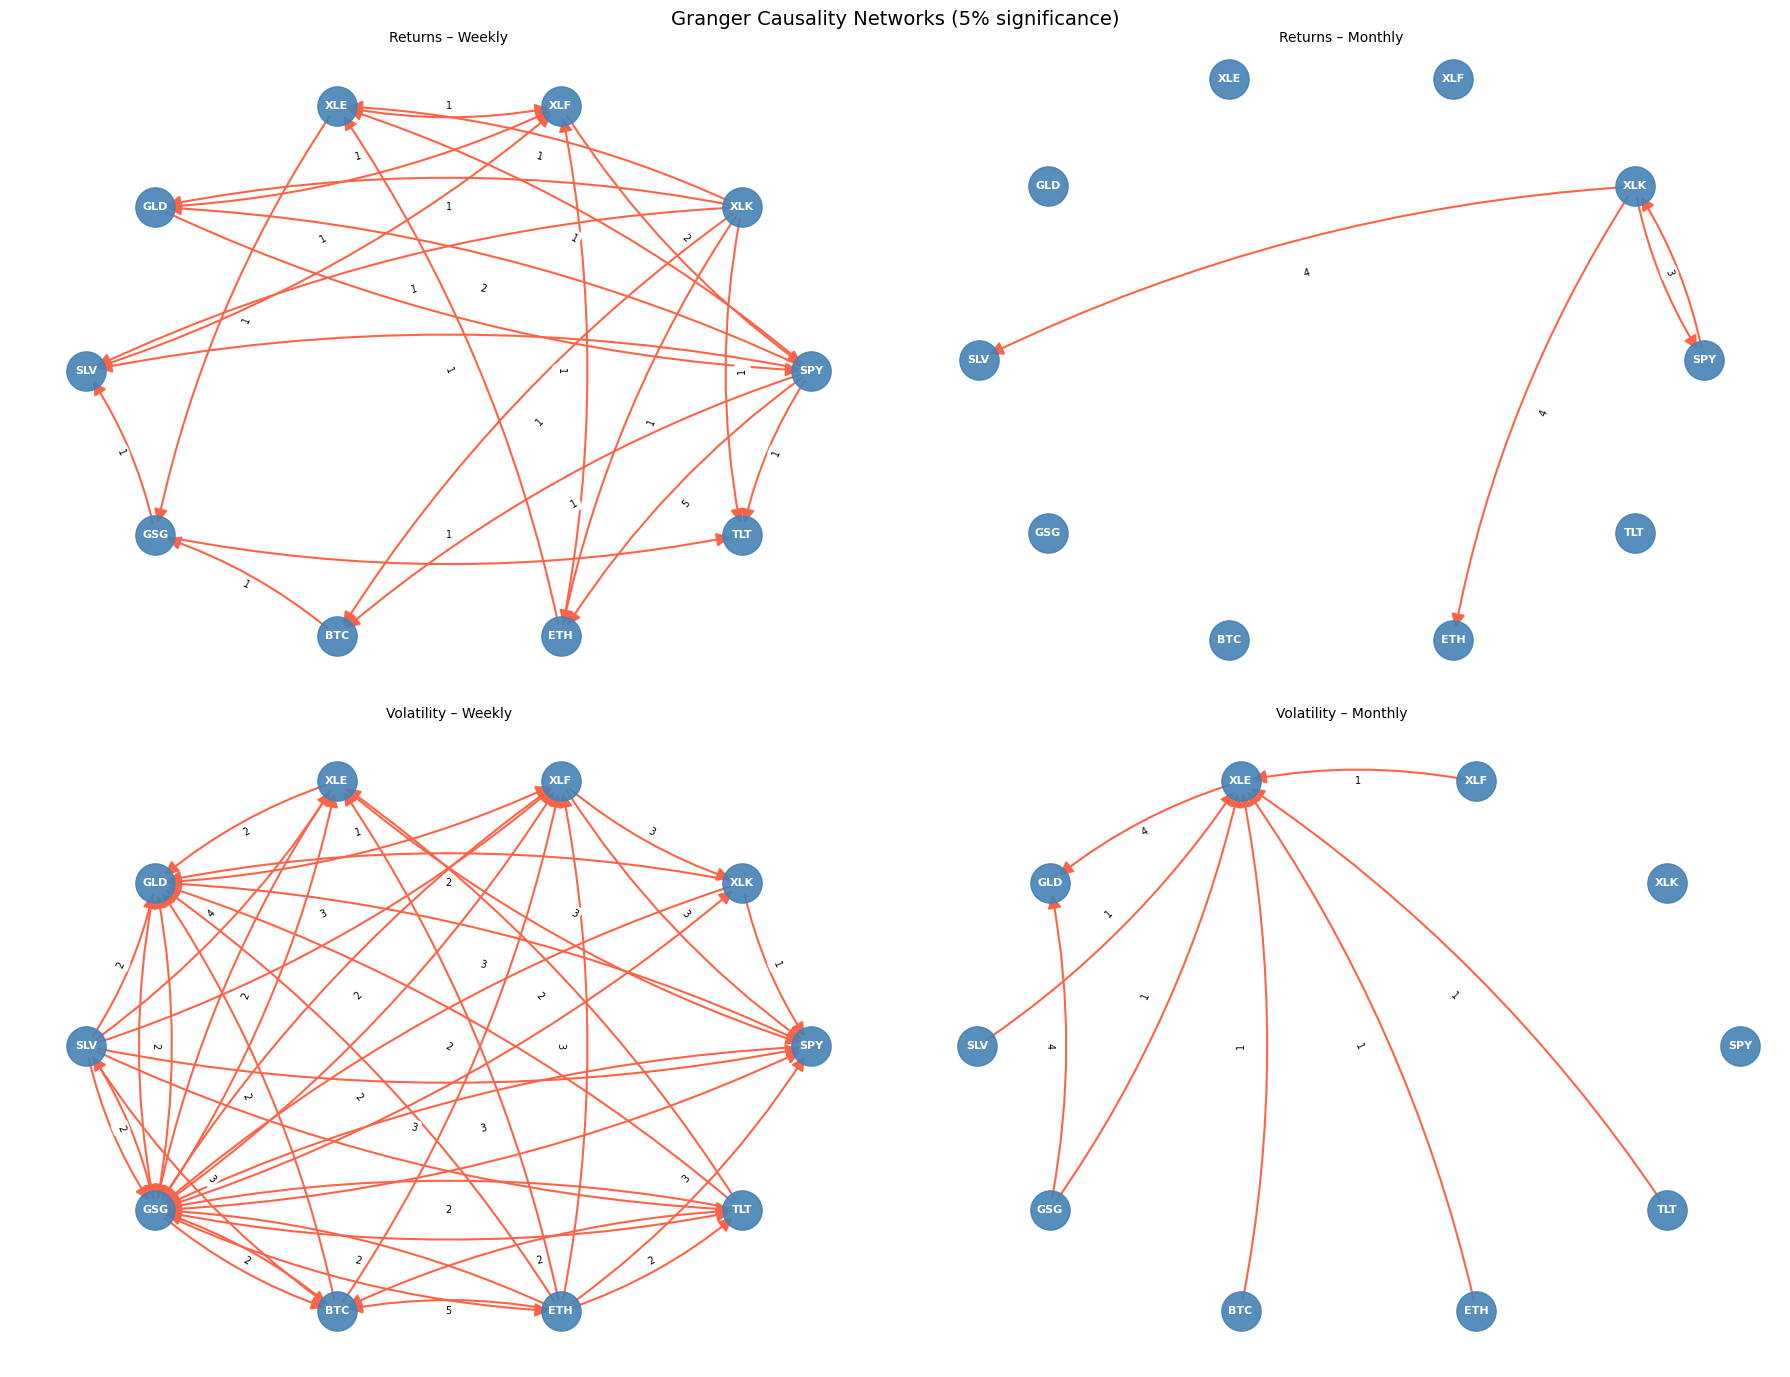

In [24]:
def plot_causality_network(table, title, ax):
    G = nx.DiGraph()
    G.add_nodes_from(table.columns)
    for cause in table.index:
        for effect in table.columns:
            if cause != effect and table.loc[cause, effect] > 0:
                G.add_edge(cause, effect, weight=int(table.loc[cause, effect]))

    pos = nx.circular_layout(G)
    edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}

    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=800, node_color='steelblue', alpha=0.9)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color='white', font_weight='bold')
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=20,
                           edge_color='tomato', width=1.5, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=7)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plot_causality_network(table_ret_weekly,  'Returns – Weekly',   axes[0,0])
plot_causality_network(table_ret_monthly, 'Returns – Monthly',  axes[0,1])
plot_causality_network(table_vol_weekly,  'Volatility – Weekly',  axes[1,0])
plot_causality_network(table_vol_monthly, 'Volatility – Monthly', axes[1,1])
plt.suptitle('Granger Causality Networks (5% significance)', fontsize=14)
plt.tight_layout()
plt.savefig('causality_networks.png', dpi=120, bbox_inches='tight')
plt.show()

## 1.7 Commentary

> **Instructions:** Edit this cell with your analysis after running the tables above.
>
> Suggested narrative points:
> - **Returns network:** Which assets drive others? E.g., does SPY lead sector ETFs (XLK, XLF, XLE)? Does BTC lead ETH?
> - **Volatility network:** Where does 'fear' spill over? Do commodity volatilities (GLD, SLV, GSG) cluster together?
> - **Weekly vs Monthly:** Do causality links disappear at lower frequency, suggesting short-term rather than structural effects?
> - **Economic interpretation:** Are any links surprising? (e.g., TLT→SPY flight-to-safety dynamics)

---
# TASK 2 – NN vs LSTM vs Gaussian Process
**Assigned features:** `bm` (Book-to-Market), `ep` (Earnings-to-Price), `ntis` (Net Equity Expansion)  
**Target:** SP500 equity premium (`GSPCep`) — we try return, and direction

## 2.1 Load Goyal-Welch Data & Build Features

In [25]:
# Upload goyal_welch2022Monthly.csv to Colab, or mount Drive
# from google.colab import files; files.upload()

gwy = pd.read_csv('/content/sample_data/goyal-welch2022Monthly.csv', parse_dates=['yyyymm'], index_col='yyyymm')
gwy.index.name = 'Date'
gwy['Index'] = pd.to_numeric(gwy['Index'], errors='coerce')

# Filter 1927-2021
gwy = gwy.loc['1927-01-01':'2021-12-31']

# ── Target: log equity premium ──
IndexDiv = gwy['Index'] + gwy['D12']
logretdiv = np.log(IndexDiv).diff()
logRfree  = np.log(gwy['Rfree'] + 1)
gwy['GSPCep'] = logretdiv - logRfree

# ── Assigned indicators ──
gwy['ep']   = np.log(gwy['E12'])   - np.log(gwy['Index'])
gwy['bm']   = gwy['b/m']
gwy['ntis'] = gwy['ntis']

# ── Lags of assigned indicators (1, 2, 3) ──
for feat in ['ep', 'bm', 'ntis']:
    for lag in [1, 2, 3]:
        gwy[f'{feat}_lag{lag}'] = gwy[feat].shift(lag)

# ── Lags of target ──
for lag in [1, 2, 3]:
    gwy[f'GSPCep_lag{lag}'] = gwy['GSPCep'].shift(lag)
gwy['GSPCep_sq_lag1'] = gwy['GSPCep'].shift(1)**2

# ── Direction target (1=up, 0=down) ──
gwy['direction'] = (gwy['GSPCep'] > 0).astype(int)

gwy.tail(3)

,Index,D12,E12,b/m,tbl,AAA,BAA,lty,ntis,Rfree,...,bm_lag2,bm_lag3,ntis_lag1,ntis_lag2,ntis_lag3,GSPCep_lag1,GSPCep_lag2,GSPCep_lag3,GSPCep_sq_lag1,direction
Date,,,,,,,,,,,,,,,,,,,,,
202010,NaN,58.6604,96.8567,0.249883,0.0010,0.0235,0.0344,0.0079,-0.001895,0.0001,...,0.232933,0.250576,-0.005698,-0.008504,-0.011998,NaN,NaN,NaN,NaN,0
202011,NaN,58.4696,95.4933,0.223435,0.0009,0.0230,0.0330,0.0087,-0.005262,0.0001,...,0.238369,0.232933,-0.001895,-0.005698,-0.008504,NaN,NaN,NaN,NaN,0
202012,NaN,58.2788,94.1300,0.216370,0.0009,0.0226,0.0316,0.0093,-0.000098,0.0001,...,0.249883,0.238369,-0.005262,-0.001895,-0.005698,NaN,NaN,NaN,NaN,0


In [27]:
# Select feature columns
FEATURE_COLS = [
    'ep', 'bm', 'ntis',
    'ep_lag1', 'ep_lag2', 'ep_lag3',
    'bm_lag1', 'bm_lag2', 'bm_lag3',
    'ntis_lag1', 'ntis_lag2', 'ntis_lag3',
    'GSPCep_lag1', 'GSPCep_lag2', 'GSPCep_lag3',
    'GSPCep_sq_lag1'
]

df_model = gwy[['GSPCep', 'direction'] + FEATURE_COLS].dropna()

# Fix index if it's still integers (yyyymm format)
if df_model.index.dtype != 'datetime64[ns]':
    df_model.index = pd.to_datetime(df_model.index.astype(str), format='%Y%m')

print(f'Full sample: {df_model.index.min().date()} to {df_model.index.max().date()}')
print(f'N = {len(df_model)} monthly observations')

# Summary stats for assigned indicators
df_model[['ep','bm','ntis','GSPCep']].describe()

Full sample: 1927-05-01 to 2009-07-01
N = 865 monthly observations


,ep,bm,ntis,GSPCep
count,865.000000,865.000000,865.000000,865.000000
mean,-2.640947,0.645750,0.021598,0.002238
std,0.382702,0.242637,0.025235,0.053949
min,-4.836482,0.171965,-0.040688,-0.332390
25%,-2.887222,0.490176,0.009924,-0.022822
50%,-2.688428,0.630337,0.020768,0.006241
75%,-2.370318,0.783752,0.029303,0.031728
max,-1.774952,2.028478,0.177040,0.327662


## 2.2 Feature Selection via Granger Causality & Lasso

In [28]:
# ── Granger causality: do our 3 indicators Granger-cause GSPCep? ──
print('=== Granger Causality: indicator → GSPCep ===\n')
for feat in ['ep', 'bm', 'ntis']:
    pair = df_model[['GSPCep', feat]].dropna()
    try:
        result = grangercausalitytests(pair, maxlag=5, verbose=False)
        pvals = {lag: result[lag][0]['ssr_ftest'][1] for lag in range(1,6)}
        best_lag = min(pvals, key=pvals.get)
        significant = pvals[best_lag] < 0.05
        print(f'{feat} → GSPCep: best lag={best_lag}, p={pvals[best_lag]:.4f} → {"SIGNIFICANT ✓" if significant else "not significant"}')
    except Exception as e:
        print(f'{feat}: error - {e}')

=== Granger Causality: indicator → GSPCep ===

ep → GSPCep: best lag=2, p=0.2022 → not significant
bm → GSPCep: best lag=4, p=0.0002 → SIGNIFICANT ✓
ntis → GSPCep: best lag=1, p=0.0049 → SIGNIFICANT ✓


In [29]:
# ── Distance correlation ──
print('=== Distance Correlation with GSPCep ===\n')
target = df_model['GSPCep'].values
for feat in FEATURE_COLS:
    x = df_model[feat].values
    dc = dcor.distance_correlation(x, target)
    print(f'{feat:25s}: dcor = {dc:.4f}')

=== Distance Correlation with GSPCep ===

ep                       : dcor = 0.1234
bm                       : dcor = 0.1621
ntis                     : dcor = 0.1381
ep_lag1                  : dcor = 0.0665
ep_lag2                  : dcor = 0.0699
ep_lag3                  : dcor = 0.0678
bm_lag1                  : dcor = 0.1003
bm_lag2                  : dcor = 0.0983
bm_lag3                  : dcor = 0.0941
ntis_lag1                : dcor = 0.1197
ntis_lag2                : dcor = 0.1187
ntis_lag3                : dcor = 0.1169
GSPCep_lag1              : dcor = 0.1282
GSPCep_lag2              : dcor = 0.0918
GSPCep_lag3              : dcor = 0.1160
GSPCep_sq_lag1           : dcor = 0.1616


In [30]:
# ── Lasso feature selection ──
X = df_model[FEATURE_COLS].values
y = df_model['GSPCep'].values

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(X_scaled, y)

coef_df = pd.DataFrame({'feature': FEATURE_COLS, 'coef': lasso.coef_})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index)
print('=== Lasso Coefficients (sorted by |coef|) ===')
print(coef_df.to_string(index=False))

selected_features = coef_df.loc[coef_df['coef'].abs() > 0, 'feature'].tolist()
print(f'\nSelected features ({len(selected_features)}): {selected_features}')

=== Lasso Coefficients (sorted by |coef|) ===
       feature      coef
       ep_lag1  0.128676
            ep -0.128063
            bm -0.100313
       bm_lag1  0.094516
          ntis -0.002521
       bm_lag3  0.001376
       ep_lag3  0.000000
       ep_lag2  0.000000
       bm_lag2  0.000000
     ntis_lag1 -0.000000
     ntis_lag2 -0.000000
     ntis_lag3 -0.000000
   GSPCep_lag1  0.000000
   GSPCep_lag2  0.000000
   GSPCep_lag3 -0.000000
GSPCep_sq_lag1 -0.000000

Selected features (6): ['ep_lag1', 'ep', 'bm', 'bm_lag1', 'ntis', 'bm_lag3']


## 2.3 Train/Test Split & Scaling

In [31]:
# Use Lasso-selected features (or all if none dropped)
FINAL_FEATURES = selected_features if len(selected_features) > 0 else FEATURE_COLS

X_all = df_model[FINAL_FEATURES].values
y_ret = df_model['GSPCep'].values
y_dir = df_model['direction'].values

# Time-series split: 80% train, 20% test
split = int(len(X_all) * 0.8)
X_train, X_test = X_all[:split], X_all[split:]
y_ret_train, y_ret_test = y_ret[:split], y_ret[split:]
y_dir_train, y_dir_test = y_dir[:split], y_dir[split:]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {split} obs | Test: {len(X_all)-split} obs')
print(f'Features used: {FINAL_FEATURES}')

Train: 692 obs | Test: 173 obs
Features used: ['ep_lag1', 'ep', 'bm', 'bm_lag1', 'ntis', 'bm_lag3']


## 2.4 Evaluation Metrics

In [32]:
def nrmse(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    var = np.mean((y_true - np.mean(y_true))**2)
    return np.sqrt(mse / var)

def pcorrect(y_true, y_pred):
    return (1 - nrmse(y_true, y_pred)) * 100

def evaluate_regressor(name, y_true, y_pred):
    print(f'\n--- {name} ---')
    print(f'  NRMSE     : {nrmse(y_true, y_pred):.4f}')
    print(f'  %Correct  : {pcorrect(y_true, y_pred):.2f}%')
    print(f'  R²        : {r2_score(y_true, y_pred):.4f}')
    return {'model': name,
            'NRMSE': nrmse(y_true, y_pred),
            'pctCorrect': pcorrect(y_true, y_pred),
            'R2': r2_score(y_true, y_pred)}

results = []

## 2.5 Neural Network (MLP)

In [33]:
# ── Hyperparameter tuning via TimeSeriesSplit ──
tscv = TimeSeriesSplit(n_splits=5)

param_grid_nn = {
    'hidden_layer_sizes': [(32,), (64,), (32, 16), (64, 32), (64, 32, 16)],
    'activation': ['relu', 'tanh'],
    'alpha': [1e-4, 1e-3, 1e-2],
    'max_iter': [500]
}

nn_base = MLPRegressor(random_state=42, early_stopping=True, validation_fraction=0.1)
gs_nn = GridSearchCV(nn_base, param_grid_nn, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
gs_nn.fit(X_train_s, y_ret_train)

print('Best NN params:', gs_nn.best_params_)
nn_best = gs_nn.best_estimator_
y_nn_pred = nn_best.predict(X_test_s)

res_nn = evaluate_regressor('Neural Network (MLP)', y_ret_test, y_nn_pred)
results.append(res_nn)

Best NN params: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (64,), 'max_iter': 500}

--- Neural Network (MLP) ---
  NRMSE     : 0.8410
  %Correct  : 15.90%
  R²        : 0.2928


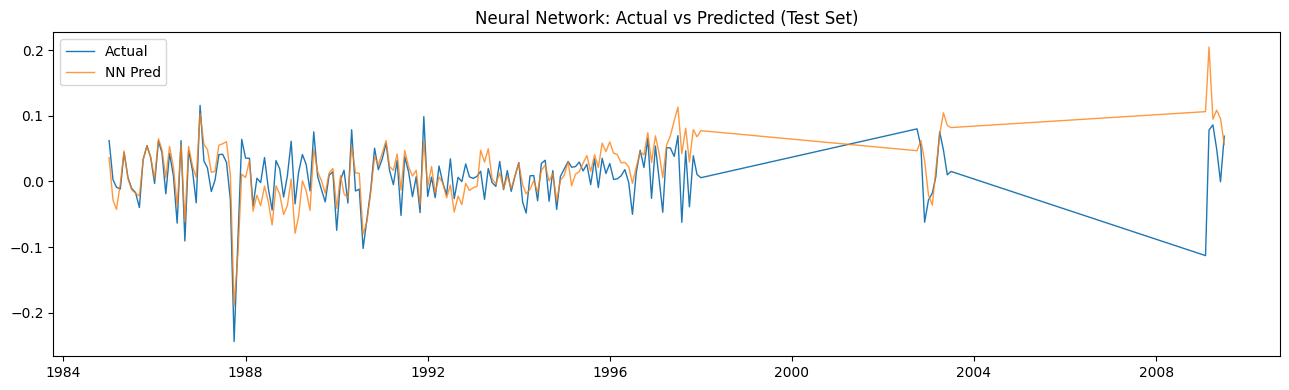

In [34]:
# Plot NN predictions
test_dates = df_model.index[split:]
plt.figure(figsize=(13, 4))
plt.plot(test_dates, y_ret_test, label='Actual', lw=1)
plt.plot(test_dates, y_nn_pred, label='NN Pred', lw=1, alpha=0.8)
plt.title('Neural Network: Actual vs Predicted (Test Set)')
plt.legend(); plt.tight_layout()
plt.savefig('nn_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.6 LSTM

In [35]:
TIMESTEPS = 12  # 12 months lookback window

def make_sequences(X, y, timesteps):
    Xs, ys = [], []
    for i in range(timesteps, len(X)):
        Xs.append(X[i-timesteps:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_lstm_all_s = scaler.fit_transform(X_all)
X_seq, y_seq = make_sequences(X_lstm_all_s, y_ret, TIMESTEPS)

split_seq = int(len(X_seq) * 0.8)
X_seq_train, X_seq_test = X_seq[:split_seq], X_seq[split_seq:]
y_seq_train, y_seq_test = y_seq[:split_seq], y_seq[split_seq:]

print(f'LSTM train shape: {X_seq_train.shape} | test: {X_seq_test.shape}')

LSTM train shape: (682, 12, 6) | test: (171, 12, 6)


In [36]:
def build_lstm(units=64, layers=1, dropout=0.2, n_features=len(FINAL_FEATURES), timesteps=TIMESTEPS):
    model = Sequential()
    model.add(Input(shape=(timesteps, n_features)))
    for i in range(layers - 1):
        model.add(LSTM(units, return_sequences=True))
        model.add(Dropout(dropout))
    model.add(LSTM(units))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# ── Try a few architectures ──
best_lstm_val = np.inf
best_lstm_model = None

configs = [
    {'units': 32, 'layers': 1, 'dropout': 0.2},
    {'units': 64, 'layers': 1, 'dropout': 0.2},
    {'units': 64, 'layers': 2, 'dropout': 0.3},
]

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

for cfg in configs:
    m = build_lstm(**cfg, n_features=X_seq_train.shape[2])
    h = m.fit(X_seq_train, y_seq_train,
               epochs=100, batch_size=32,
               validation_split=0.1,
               callbacks=[early_stop],
               verbose=0)
    val_loss = min(h.history['val_loss'])
    print(f'Config {cfg} → best val_loss: {val_loss:.6f}')
    if val_loss < best_lstm_val:
        best_lstm_val = val_loss
        best_lstm_model = m
        best_cfg = cfg

print(f'\nBest LSTM config: {best_cfg}')

Config {'units': 32, 'layers': 1, 'dropout': 0.2} → best val_loss: 0.001740
Config {'units': 64, 'layers': 1, 'dropout': 0.2} → best val_loss: 0.001696
Config {'units': 64, 'layers': 2, 'dropout': 0.3} → best val_loss: 0.001690

Best LSTM config: {'units': 64, 'layers': 2, 'dropout': 0.3}


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

--- LSTM ---
  NRMSE     : 1.1450
  %Correct  : -14.50%
  R²        : -0.3111


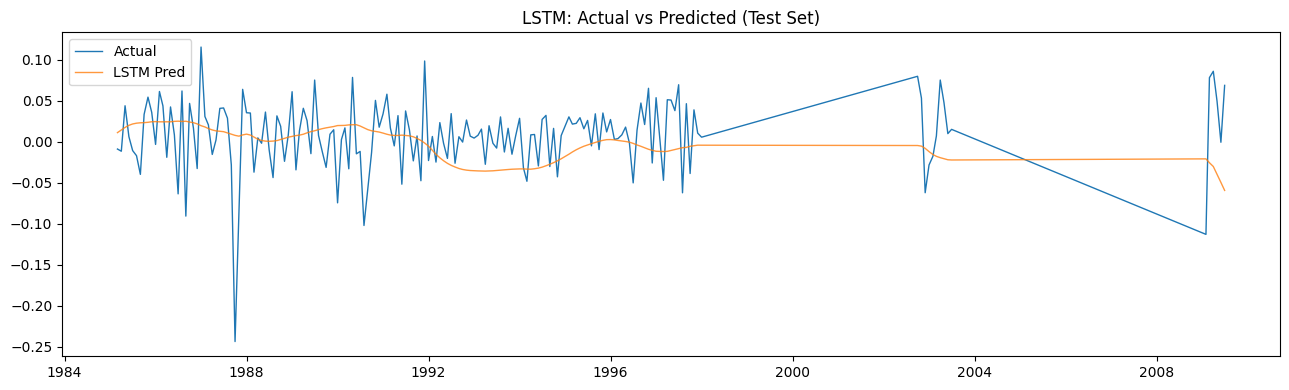

In [37]:
y_lstm_pred = best_lstm_model.predict(X_seq_test).flatten()
res_lstm = evaluate_regressor('LSTM', y_seq_test, y_lstm_pred)
results.append(res_lstm)

test_dates_lstm = df_model.index[split_seq + TIMESTEPS:]
plt.figure(figsize=(13, 4))
plt.plot(test_dates_lstm, y_seq_test, label='Actual', lw=1)
plt.plot(test_dates_lstm, y_lstm_pred, label='LSTM Pred', lw=1, alpha=0.8)
plt.title('LSTM: Actual vs Predicted (Test Set)')
plt.legend(); plt.tight_layout()
plt.savefig('lstm_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.7 Gaussian Process

In [38]:
# Try multiple kernels
kernels = {
    'RBF':             C(1.0) * RBF(1.0) + WhiteKernel(),
    'Matern (nu=1.5)': C(1.0) * Matern(nu=1.5) + WhiteKernel(),
    'Matern (nu=2.5)': C(1.0) * Matern(nu=2.5) + WhiteKernel(),
    'DotProduct':      C(1.0) * DotProduct() + WhiteKernel(),
    'RBF+DotProduct':  C(1.0) * RBF(1.0) + C(1.0) * DotProduct() + WhiteKernel(),
}

# GP works best on smaller data; use last 300 obs for training for speed
GP_TRAIN_SIZE = 300
X_gp_train = X_train_s[-GP_TRAIN_SIZE:]
y_gp_train = y_ret_train[-GP_TRAIN_SIZE:]

best_gp_r2 = -np.inf
best_gp_model = None
best_gp_kernel_name = ''

for name, kernel in kernels.items():
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3, normalize_y=True)
    gp.fit(X_gp_train, y_gp_train)
    y_gp_pred_train = gp.predict(X_gp_train)
    r2 = r2_score(y_gp_train, y_gp_pred_train)
    print(f'Kernel: {name:25s} | Train R²: {r2:.4f}')
    if r2 > best_gp_r2:
        best_gp_r2 = r2
        best_gp_model = gp
        best_gp_kernel_name = name

print(f'\nBest kernel: {best_gp_kernel_name}')

Kernel: RBF                       | Train R²: 0.9607
Kernel: Matern (nu=1.5)           | Train R²: 0.9774
Kernel: Matern (nu=2.5)           | Train R²: 0.9618
Kernel: DotProduct                | Train R²: 0.9512
Kernel: RBF+DotProduct            | Train R²: 0.9977

Best kernel: RBF+DotProduct



--- Gaussian Process (RBF+DotProduct) ---
  NRMSE     : 0.7822
  %Correct  : 21.78%
  R²        : 0.3881


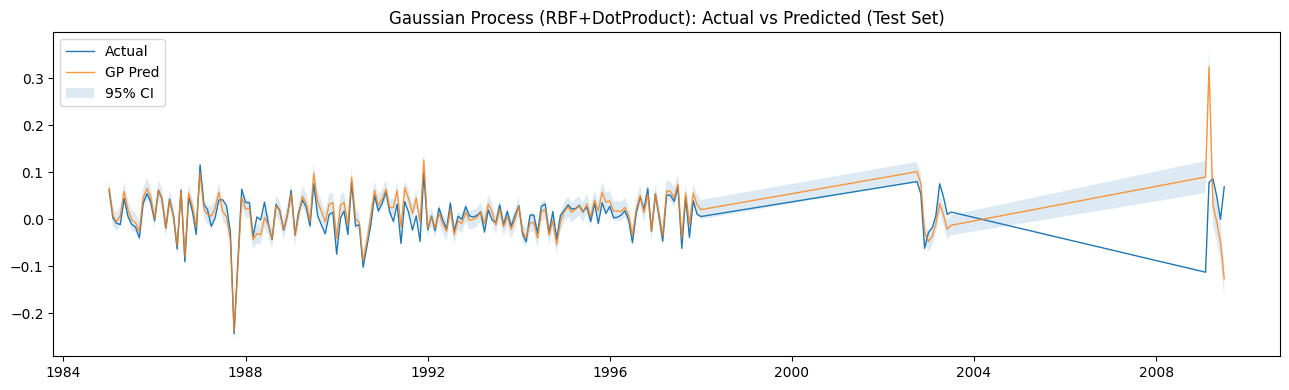

In [39]:
y_gp_pred, y_gp_std = best_gp_model.predict(X_test_s, return_std=True)
res_gp = evaluate_regressor(f'Gaussian Process ({best_gp_kernel_name})', y_ret_test, y_gp_pred)
results.append(res_gp)

plt.figure(figsize=(13, 4))
plt.plot(test_dates, y_ret_test, label='Actual', lw=1)
plt.plot(test_dates, y_gp_pred, label='GP Pred', lw=1, alpha=0.8)
plt.fill_between(test_dates, y_gp_pred - 1.96*y_gp_std, y_gp_pred + 1.96*y_gp_std, alpha=0.15, label='95% CI')
plt.title(f'Gaussian Process ({best_gp_kernel_name}): Actual vs Predicted (Test Set)')
plt.legend(); plt.tight_layout()
plt.savefig('gp_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.8 Sensitivity Analysis

=== Sensitivity Analysis (leave-one-feature-out, NN) ===

Baseline NRMSE (all features): 0.8410

  Drop ep_lag1                  : NRMSE=1.1264  Δ=+0.2854
  Drop ep                       : NRMSE=1.4023  Δ=+0.5613
  Drop bm                       : NRMSE=1.3326  Δ=+0.4917
  Drop bm_lag1                  : NRMSE=1.3535  Δ=+0.5126
  Drop ntis                     : NRMSE=1.5158  Δ=+0.6749
  Drop bm_lag3                  : NRMSE=1.0155  Δ=+0.1745


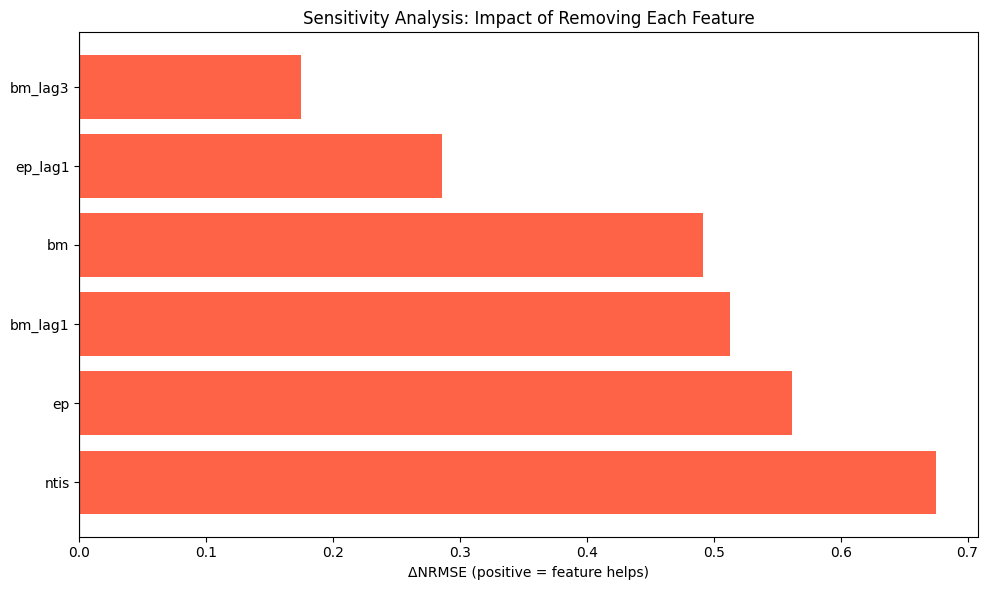

In [40]:
# Leave-one-feature-out sensitivity using best NN
print('=== Sensitivity Analysis (leave-one-feature-out, NN) ===\n')
baseline_nrmse = nrmse(y_ret_test, nn_best.predict(X_test_s))
print(f'Baseline NRMSE (all features): {baseline_nrmse:.4f}\n')

sensitivity = []
for i, feat in enumerate(FINAL_FEATURES):
    X_tr_drop = np.delete(X_train_s, i, axis=1)
    X_te_drop  = np.delete(X_test_s,  i, axis=1)
    params = gs_nn.best_params_.copy()
    params.pop('max_iter', None)
    nn_drop = MLPRegressor(random_state=42, early_stopping=True, max_iter=500, **params)
    nn_drop.fit(X_tr_drop, y_ret_train)
    drop_nrmse = nrmse(y_ret_test, nn_drop.predict(X_te_drop))
    delta = drop_nrmse - baseline_nrmse
    sensitivity.append({'feature': feat, 'NRMSE_without': drop_nrmse, 'delta': delta})
    print(f'  Drop {feat:25s}: NRMSE={drop_nrmse:.4f}  Δ={delta:+.4f}')

sens_df = pd.DataFrame(sensitivity).sort_values('delta', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if d > 0 else 'steelblue' for d in sens_df['delta']]
ax.barh(sens_df['feature'], sens_df['delta'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('ΔNRMSE (positive = feature helps)')
ax.set_title('Sensitivity Analysis: Impact of Removing Each Feature')
plt.tight_layout()
plt.savefig('sensitivity.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.9 Model Comparison Summary

In [41]:
res_df = pd.DataFrame(results)
print('\n=== Task 2 Model Comparison (Return Prediction) ===')
print(tabulate(res_df, headers='keys', tablefmt='grid', floatfmt='.4f', showindex=False))


=== Task 2 Model Comparison (Return Prediction) ===
+-----------------------------------+---------+--------------+---------+
| model                             |   NRMSE |   pctCorrect |      R2 |
+===================================+=========+==============+=========+
| Neural Network (MLP)              |  0.8410 |      15.9028 |  0.2928 |
+-----------------------------------+---------+--------------+---------+
| LSTM                              |  1.1450 |     -14.5047 | -0.3111 |
+-----------------------------------+---------+--------------+---------+
| Gaussian Process (RBF+DotProduct) |  0.7822 |      21.7767 |  0.3881 |
+-----------------------------------+---------+--------------+---------+


---
# TASK 3 – ARMA(p,q) + GARCH(1,1) Baseline

## 3.1 Normalizing Transformations

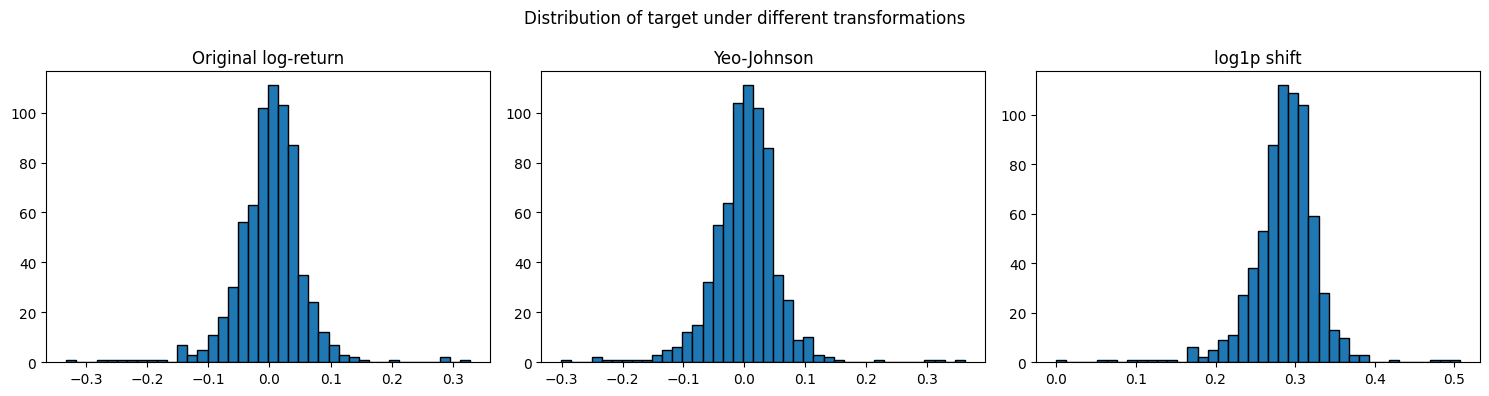

Yeo-Johnson λ = 1.6740


In [42]:
from scipy.stats import boxcox, yeojohnson
from scipy.special import inv_boxcox

target_train = y_ret_train.copy()
target_test  = y_ret_test.copy()

# Log-return is already a normalizing transformation.
# We additionally try Yeo-Johnson (handles negatives, unlike Box-Cox)

yj_train, lam_yj = yeojohnson(target_train)
yj_test  = yeojohnson(target_test, lam_yj)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(target_train, bins=40, edgecolor='k'); axes[0].set_title('Original log-return')
axes[1].hist(yj_train,     bins=40, edgecolor='k'); axes[1].set_title('Yeo-Johnson')
axes[2].hist(np.log1p(target_train - target_train.min()), bins=40, edgecolor='k'); axes[2].set_title('log1p shift')
plt.suptitle('Distribution of target under different transformations')
plt.tight_layout()
plt.savefig('normalizations.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Yeo-Johnson λ = {lam_yj:.4f}')

## 3.2 ARMA Order Selection & GARCH(1,1) Fit

In [43]:
# Select ARMA order on training set using AIC
from itertools import product as iproduct

best_aic = np.inf
best_pq = (1, 0)

for p, q in iproduct(range(0, 4), range(0, 4)):
    try:
        m = sm.tsa.ARIMA(target_train, order=(p, 0, q)).fit()
        if m.aic < best_aic:
            best_aic = m.aic
            best_pq = (p, q)
    except:
        pass

print(f'Best ARMA order: p={best_pq[0]}, q={best_pq[1]} (AIC={best_aic:.2f})')

Best ARMA order: p=2, q=2 (AIC=-2032.74)


In [44]:
# Fit ARMA(p,q) + GARCH(1,1) using arch library
p_opt, q_opt = best_pq

garch_model = arch_model(
    target_train * 100,   # scale for numerical stability
    mean='ARX',
    lags=p_opt if p_opt > 0 else None,
    vol='GARCH',
    p=1, q=1,
    dist='normal'
)
garch_fit = garch_model.fit(disp='off')
print(garch_fit.summary())

                           AR - GARCH Model Results                           
Dep. Variable:                      y   R-squared:                       0.005
Mean Model:                        AR   Adj. R-squared:                  0.002
Vol Model:                      GARCH   Log-Likelihood:               -2044.58
Distribution:                  Normal   AIC:                           4101.16
Method:            Maximum Likelihood   BIC:                           4128.38
                                        No. Observations:                  690
Date:                Wed, May 06 2026   Df Residuals:                      687
Time:                        09:14:40   Df Model:                            3
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.2732      0.161      1.694  9.032e-02 [-4.29

In [45]:
# Rolling one-step-ahead forecast on test set
n_test = len(target_test)
y_garch_pred = []

# Expand window forecast
full_series = np.concatenate([target_train, target_test]) * 100

for i in range(n_test):
    train_window = full_series[:len(target_train) + i]
    try:
        m = arch_model(train_window, mean='ARX',
                       lags=p_opt if p_opt > 0 else None,
                       vol='GARCH', p=1, q=1, dist='normal')
        r = m.fit(disp='off', show_warning=False)
        fc = r.forecast(horizon=1, reindex=False)
        y_garch_pred.append(fc.mean.values.flatten()[0] / 100)
    except:
        y_garch_pred.append(np.mean(target_train))

y_garch_pred = np.array(y_garch_pred)
res_garch = evaluate_regressor(f'ARMA({p_opt},{q_opt})+GARCH(1,1)', target_test, y_garch_pred)
results.append(res_garch)
print('Done.')


--- ARMA(2,2)+GARCH(1,1) ---
  NRMSE     : 1.0076
  %Correct  : -0.76%
  R²        : -0.0152
Done.


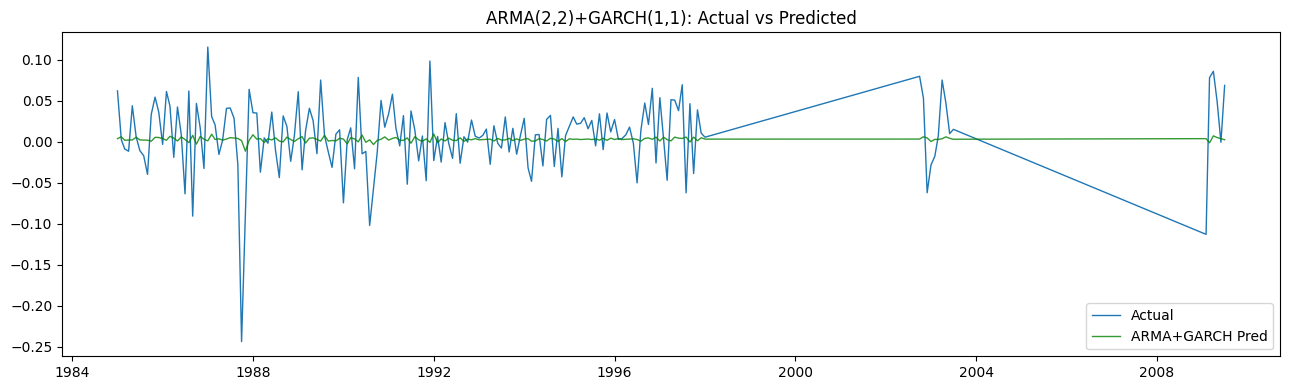

In [46]:
plt.figure(figsize=(13, 4))
plt.plot(test_dates, target_test, label='Actual', lw=1)
plt.plot(test_dates, y_garch_pred, label='ARMA+GARCH Pred', lw=1, alpha=0.8, color='green')
plt.title(f'ARMA({p_opt},{q_opt})+GARCH(1,1): Actual vs Predicted')
plt.legend(); plt.tight_layout()
plt.savefig('garch_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

## 3.3 Final Comparison: All Models


=== Final Model Comparison ===
+-----------------------------------+---------+--------------+---------+
| model                             |   NRMSE |   pctCorrect |      R2 |
+===================================+=========+==============+=========+
| Neural Network (MLP)              |  0.8410 |      15.9028 |  0.2928 |
+-----------------------------------+---------+--------------+---------+
| LSTM                              |  1.1450 |     -14.5047 | -0.3111 |
+-----------------------------------+---------+--------------+---------+
| Gaussian Process (RBF+DotProduct) |  0.7822 |      21.7767 |  0.3881 |
+-----------------------------------+---------+--------------+---------+
| ARMA(2,2)+GARCH(1,1)              |  1.0076 |      -0.7582 | -0.0152 |
+-----------------------------------+---------+--------------+---------+


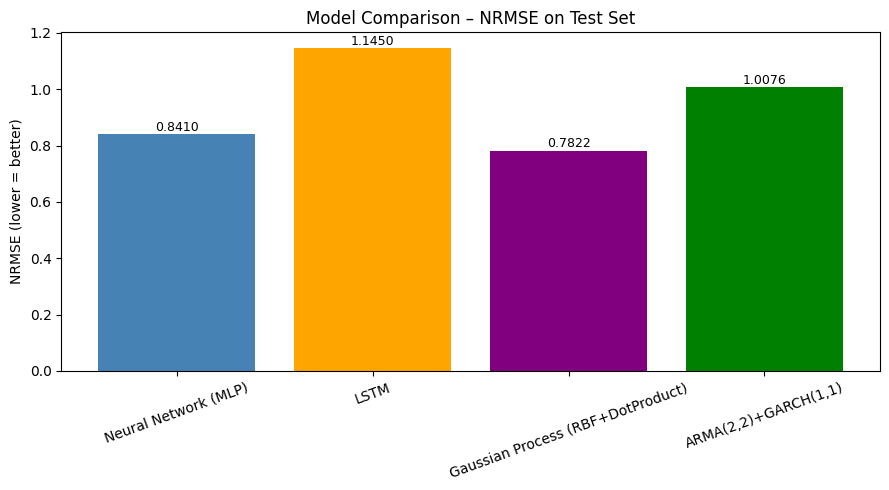

In [47]:
res_df_all = pd.DataFrame(results)
print('\n=== Final Model Comparison ===')
print(tabulate(res_df_all, headers='keys', tablefmt='grid', floatfmt='.4f', showindex=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue', 'orange', 'purple', 'green']
bars = ax.bar(res_df_all['model'], res_df_all['NRMSE'], color=colors[:len(res_df_all)])
ax.set_ylabel('NRMSE (lower = better)')
ax.set_title('Model Comparison – NRMSE on Test Set')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, res_df_all['NRMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 3.4 Commentary on Task 3

> **Instructions:** Edit this cell after you have results.
>
> Points to address:
> - Does the ARMA+GARCH baseline beat or get beaten by NN/LSTM/GP?
> - Which normalization transformation helped most?
> - What do the GARCH volatility estimates tell us about turbulent periods (e.g., 2008, 2020)?
> - Is the additional complexity of deep learning economically meaningful?

---
# TASK 4 – Lecture Summaries (2–3 key points each)

## Lecture 1 – Financial Time Series & Volatility
1. **Key point 1:** *e.g., Returns are approximately stationary while prices are non-stationary (random walk). Working with log-returns is a standard normalisation.*
2. **Key point 2:** *e.g., Volatility clusters in time and is time-varying; EWMA and GARCH(1,1) capture this by weighting recent squared returns more heavily.*
3. **Key point 3:** *e.g., Fat tails and negative skewness are stylised facts of return distributions, invalidating the i.i.d. Gaussian assumption.*

## Lecture 2 – Causality & VAR Models
1. **Key point 1:** *e.g., Granger causality tests whether past values of X improve the forecast of Y beyond Y's own past — it is predictive, not mechanistic, causality.*
2. **Key point 2:** *e.g., Lag order selection via AIC balances model fit against complexity; under-specifying lags can miss genuine causal effects.*
3. **Key point 3:** *e.g., Volatility spillover (applying Granger causality to EWMA series) reveals 'fear contagion' across markets — often stronger and more widespread than return causality.*

## Lecture 3 – Feature Selection & Correlation
1. **Key point 1:** *e.g., Standard Pearson correlation only captures linear dependence; distance correlation (dcor) detects any type of statistical dependence.*
2. **Key point 2:** *e.g., Lasso performs simultaneous estimation and feature selection by shrinking irrelevant coefficients to exactly zero.*
3. **Key point 3:** *e.g., Overfitting is a serious risk with many candidate predictors; time-series cross-validation (expanding or rolling window) is essential to get honest out-of-sample estimates.*

## Lecture 4 – Neural Networks & LSTM
1. **Key point 1:** *e.g., MLPs approximate arbitrary non-linear functions; depth (layers) vs width (units) trade-offs affect expressiveness and risk of overfitting.*
2. **Key point 2:** *e.g., LSTMs solve the vanishing gradient problem in RNNs via gating mechanisms (forget, input, output gates), making them suited to long-term sequential dependencies.*
3. **Key point 3:** *e.g., Early stopping and dropout are critical regularisation tools to prevent LSTM overfitting on small financial datasets.*

## Lecture 5 – Gaussian Processes
1. **Key point 1:** *e.g., A GP is a distribution over functions; the kernel (covariance function) encodes prior beliefs about smoothness, periodicity, and trend.*
2. **Key point 2:** *e.g., GPs provide uncertainty quantification (predictive intervals) for free — valuable in finance where knowing model confidence matters.*
3. **Key point 3:** *e.g., Stationary kernels (RBF, Matérn) assume the function has the same behaviour everywhere; non-stationary kernels (DotProduct, custom) can capture trends and regime changes.*

---
# Author Contributions- all authors contributed equally